## Imports

In [27]:
import os
import gc
import time
import json
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import cv2 as cv
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sn
from tqdm import tqdm
from datetime import datetime
from torch.utils.data import DataLoader
from torch.amp import GradScaler  # Updated GradScaler import

# PyTorch utilities
import sys
# Load pytorch utils from one level below
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..' )))

from pytorch_utils.training_utils import *
import pytorch_utils.training_utils as pt_train

# Hyperparameter tuning
from hyperopt import hp, STATUS_OK, fmin, tpe, space_eval, Trials
from hyperopt.pyll import scope

# Captum for interpretability
from captum.attr import Saliency
from captum.attr import visualization as viz
from matplotlib.colors import LinearSegmentedColormap

# TorchMetrics
from torchmetrics import ConfusionMatrix

# GradCAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Get default Matplotlib backend
default_matplotlib_backend = matplotlib.get_backend()
print("Imported")
print(f"Default Matplotlib backend: {default_matplotlib_backend}")


Imported
Default Matplotlib backend: module://matplotlib_inline.backend_inline


# Single Image Plant Classification - Configuration Setup

This section sets up the configuration for the plant classification model.

## Key Components

1. **RUN_MODE**: Controls whether to run in development (DEV) or production (LIVE) mode
    - LIVE: Uses full dataset and more epochs for production training 

2. **Path Configuration**: Sets up all necessary directories for the project
   - datasets/: Contains the plant image dataset
   - weights/: Stores model weights during training
   - stats/: Stores training statistics and metrics
   - npy_data/: Stores preprocessed numpy arrays
   - model/: Stores the final trained model

3. **Model Configuration**: Defines hyperparameters and model architecture
   - Backbone: The pre-trained CNN or Transformer architecture to use
   - Optimizer: The optimization algorithm
   - Batch size, epochs, image size, etc.

4. **Device Selection**: Automatically detects and uses GPU if available

Subsequent cells will use these configurations for data loading, model creation, training, and evaluation.

In [28]:
import os
import numpy as np
import torch

# Set random seed for reproducibility
np.random.seed(42)

# =============================================================================
# RUN MODE CONFIGURATION
# =============================================================================
RUN_MODE = "LIVE"  # Options: "DEV" (development) or "LIVE" (production)
USE_TWO_GPUS = True

# =============================================================================
# PATH CONFIGURATION
# =============================================================================
# Get the current working directory as the project root
root_path = os.getcwd()

# =============================================================================
# DEVICE CONFIGURATION
# =============================================================================
# Automatically detect and use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Selected device: {device}')

if device.type == 'cuda':
    print(f'GPU Device: {torch.cuda.get_device_name(device)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(device).total_memory / 1e9:.1f} GB')

# =============================================================================
# MODEL HYPERPARAMETERS
# =============================================================================
# Training parameters based on run mode
BATCH_SIZE = 64
EPOCHS = 30
print("Running in PRODUCTION mode - full dataset and epochs")

# Image processing parameters
IMG_SIZE = (350, 350)
RESIZE_SHAPE = (350, 350)
NUM_CHANNELS = 3


# =============================================================================
# CONFIGURATION SUMMARY
# =============================================================================
print("\n" + "="*60)
print("CONFIGURATION SUMMARY")
print("="*60)
print(f"Run Mode: {RUN_MODE}")
print(f"Device: {device}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Image Size: {IMG_SIZE}")
print("="*60)

Selected device: cuda
GPU Device: NVIDIA RTX A6000
GPU Memory: 50.9 GB
Running in PRODUCTION mode - full dataset and epochs

CONFIGURATION SUMMARY
Run Mode: LIVE
Device: cuda
Batch Size: 64
Epochs: 30
Image Size: (350, 350)


# Data Loading and Processing

This section handles the loading and preparation of the plant image dataset for classification.

## Key Components

1. **Dataset Selection**:
   - Uses a JSON file (`NEW25split.json`) or (`NEW8split.json`) to define the train/validation/test split
   - Supports different dataset paths based on the chosen JSON file

2. **Data Loading Process**:
   - Loads all image files and their corresponding class targets
   - Creates a mapping from class names to numerical indices
   - Organizes images by class and repetition

3. **Data Caching**:
   - Saves processed images as NumPy arrays (.npy files) for faster loading in future runs
   - Stores both images and targets for efficient retrieval

4. **Train/Validation/Test Split**:
   - Applies the split defined in the JSON configuration file
   - Ensures proper distribution of classes across training, validation, and test sets
   - Maintains class balance in the dataset splits

The resulting data will be used to create PyTorch DataLoader objects for model training and evaluation.

In [31]:
# Configuration dictionary for dataset settings
DATASET_CONFIG = {
    'split_json': 'NEW8split.json',  # JSON file defining train/valid/test split
    'dataset_paths': {
        'NEW8split.json': "ADD PATH HERE",
        'NEW25split.json': "ADD PATH HERE"
    },
    'save_path': '/home/rsaric/plant_class/npy'
}

# Helper functions for data loading
def get_dataset_path(config):
    """Determine the dataset path based on the configuration"""
    json_name = config['split_json']
    if json_name in config['dataset_paths']:
        return config['dataset_paths'][json_name]
    else:
        raise ValueError(f"Unknown JSON file: {json_name}")

def load_image_files_and_targets(data_path, class_dict):
    """Load all image files and their corresponding targets"""
    image_files = []
    targets = []
    
    for class_name in class_dict.keys():
        repetitions_list = os.listdir(os.path.join(data_path, class_name))
        repetitions_list.sort()
        for repetition in repetitions_list:
            image_list = os.listdir(os.path.join(data_path, class_name, repetition))
            image_list.sort()
            image_files.extend(
                [os.path.join(data_path, class_name, repetition, img) for img in image_list]
            )
            targets.extend([class_dict[class_name]] * len(image_list))
    
    return image_files, np.array(targets)

def process_and_save_images(image_files, targets, save_path):
    """Process images and save them as numpy arrays"""
    images = np.empty((len(image_files), NUM_CHANNELS, 350, 350), dtype=np.uint8)
    for idx, img_path in enumerate(tqdm(image_files, position=0, leave=True)):
        img = cv.imread(img_path)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = cv.resize(img, (350, 350))
        img = img.transpose(2, 0, 1)
        images[idx] = img

    # Save images and targets
    with open(os.path.join(save_path, 'images.npy'), 'wb') as npy_images_file, \
         open(os.path.join(save_path, 'targets.npy'), 'wb') as npy_targets_file:
        np.save(npy_images_file, images, allow_pickle=True)
        np.save(npy_targets_file, targets, allow_pickle=True)
    
    # Save image file paths
    with open(os.path.join(save_path, 'image_files.json'), 'w') as f:
        json.dump(image_files, f)
    
    return images


# Main execution
# 1. Set up dataset path
extracted_data_path = get_dataset_path(DATASET_CONFIG)
save_path = DATASET_CONFIG['save_path']
if os.path.exists(extracted_data_path):

    class_list = sorted(os.listdir(extracted_data_path))
    
    print(f'Number of classes: {len(class_list)}')
    print(f'Classes: {class_list}')
else:
    class_list = []
    print(f"Warning: Dataset path does not exist: {extracted_data_path}")
    print("Please ensure the dataset is properly downloaded and extracted.")

# 2. Get class list
class_list = os.listdir(extracted_data_path)
class_list.sort()

# 3. Create class to index mapping
class_dict = {class_name: i for i, class_name in enumerate(class_list)}

# 4. Load image files and targets
print('Loading data...')
image_files, targets = load_image_files_and_targets(extracted_data_path, class_dict)

# 5. Process and save images if not already saved
if not os.path.exists(os.path.join(save_path, 'images.npy')):
    print(f'Saving data as .npy files to {save_path}')
    images = process_and_save_images(image_files, targets, save_path)
    print('Data files saved')
else:
    print('Loading data from saved .npy files')
    images = np.load(os.path.join(save_path, 'images.npy'))
    targets = np.load(os.path.join(save_path, 'targets.npy'))

# 6. Apply train/valid/test split from JSON
with open(os.path.join(root_path, DATASET_CONFIG['split_json']), 'r') as f:
    image_files_dict_cut = json.load(f)

# 7. Update class list based on JSON
classes_to_use = sorted(list(image_files_dict_cut.keys()))
mapper_allcls_to_subcls = {class_dict[cls_name]: i for i, cls_name in enumerate(classes_to_use)}
class_dict = {cls_name: i for i, cls_name in enumerate(classes_to_use)}
class_list = classes_to_use

# 8. Filter targets and image files based on classes in JSON
new_targets = []
new_image_files = []
for t, im in zip(targets, image_files):
    if t in mapper_allcls_to_subcls:
        new_targets.append(mapper_allcls_to_subcls[t])
        new_image_files.append(im)
targets = np.array(new_targets)
image_files = new_image_files

# 9. Split images into train, validation, and test sets
train_images_idxs, val_images_idxs, test_images_idxs = [], [], []

for image_file_idx, image_file_name in enumerate(image_files):
    _class, rep_num, im_name = image_file_name.split(os.sep)[-3:]
    
    if (_class not in image_files_dict_cut) or (rep_num not in image_files_dict_cut[_class]):
        continue
    
    split_type = image_files_dict_cut[_class][rep_num]
    if split_type == 'train':
        train_images_idxs.append(image_file_idx)
    elif split_type == 'valid':
        val_images_idxs.append(image_file_idx)
    elif split_type == 'test':
        test_images_idxs.append(image_file_idx)

# 10. Create final dataset splits
train_images = images[train_images_idxs]
val_images = images[val_images_idxs]
test_images = images[test_images_idxs]

train_targets = targets[train_images_idxs]
val_targets = targets[val_images_idxs]
test_targets = targets[test_images_idxs]

# 11. Verify dataset integrity
assert len(train_images) == len(train_targets), "Training images and targets mismatch"
assert len(test_images) == len(test_targets), "Test images and targets mismatch"
assert len(val_images) == len(val_targets), "Validation images and targets mismatch"

# 12. Print dataset statistics
print(f'Number of training images: {len(train_images)}')
print(f'Number of validation images: {len(val_images)}')
print(f'Number of test images: {len(test_images)}')

Number of classes: 8
Classes: ['Col-0', 'Cvi-0', 'Is-1', 'Kz-9', 'Ler-1', 'TOU-I-17', 'Uk-1', 'Zdr-1']
Loading data...
Loading data from saved .npy files
Number of training images: 10787
Number of validation images: 1371
Number of test images: 3242


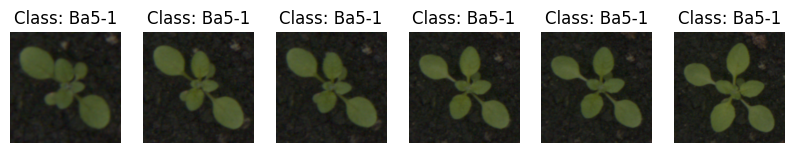

In [4]:
to_plot_from_train = 6

plt.figure(figsize=(10, 10))
for i in range(to_plot_from_train):
    plt.subplot(1, to_plot_from_train, i + 1)
    img = train_images[i].swapaxes(0,2)
    plt.imshow((img).astype(np.uint8))
    plt.title('Class: {}'.format(class_list[train_targets[i]]))
    plt.axis('off')

plt.show()

#### Dataset class and data loaders
By loading the whole dataset inside the memory, it because very easy to train the model. All we have to do is normalise the images (divide by 255 and change into C, W, H format) then return it with it's corresponding target class

- Data augmentation can be turned on/off by modifying this code (more details in comments at the end)

In [32]:
# Define whether to use data augmentation
USE_AUGMENTATION = False

# Define the dataset class for classification
class ClassificationPlantDataset(torch.utils.data.Dataset):
    def __init__(self, images, targets, transform=None):
        self.images = images
        self.targets = targets
        self.transform = transform

    def __getitem__(self, index):
        # Normalize image data
        image = torch.tensor(self.images[index]).type(torch.float32) / 255

        # Apply transformation if provided
        if self.transform:
            image = self.transform(image)

        target = torch.tensor(self.targets[index])
        return image, target

    def __len__(self):
        return len(self.images)

# Create train dataset
if USE_AUGMENTATION:
    train_transforms = T.Compose([
        # Data augmentation effects
        T.RandomAffine(degrees=(-180, 180), translate=(0.2, 0.2), scale=(0.8, 1.5)),
        T.RandomHorizontalFlip(),
        T.RandomRotation([45, 270])
    ])
else:
    train_transforms = None

train_dataset = ClassificationPlantDataset(train_images, train_targets, transform=train_transforms)

# Create validation and test datasets
val_dataset = ClassificationPlantDataset(val_images, val_targets, transform=None)
test_dataset = ClassificationPlantDataset(test_images, test_targets, transform=None)

# Combine validation and test datasets
val_dataset = torch.utils.data.ConcatDataset([val_dataset, test_dataset])
test_dataset = val_dataset

# Data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=True, drop_last=False)

print('Data loaders created')


Data loaders created


### Data sample (Run this only if you want to see an example of the augmented data)


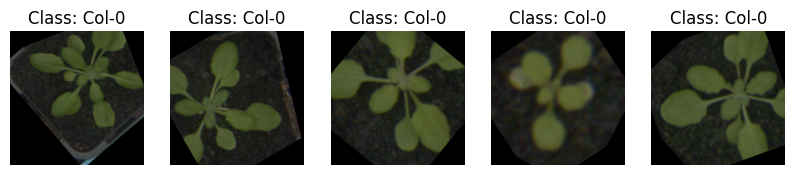

In [15]:
dataset = train_dataset

sample_size = 5
class_name = "Col-0"
img_idx = np.random.randint(0, len(dataset), size=75)
sample = [dataset[i] for i in img_idx]

plt.figure(figsize=(10, 10))
cnt = 0
for i in range(70):
    if cnt >= sample_size:
        break
    
    if class_name.lower() == class_list[sample[i][1]].lower():
        plt.subplot(1, sample_size, cnt + 1)
        img = sample[i][0].cpu().permute(1, 2, 0)
        plt.imshow((img * 255).type(torch.uint8))
        plt.title('Class: {}'.format(class_list[sample[i][1]]))
        plt.axis('off')
        cnt += 1

plt.show()

##  Utility functions

## Training and evaluation functions

`_handlezero_division_np(a, b)` performs safe element-wise division of arrays `a / b`, assigning 0 where `b == 0`. 

The `mathews_correlation_coefficient_np(tp, fp, fn, tn)` function computes the Matthews Correlation Coefficient (MCC), a balanced binary classification metric even under class imbalance. It uses the standard MCC formula and includes an `eps` term to prevent divide-by-zero errors.

MCC ranges from -1 (total disagreement) to +1 (perfect prediction), with 0 indicating random performance.


In [33]:
def _handlezero_division_np(a,b):
    # initialize output tensor with desired value
    c = np.zeros_like(a)
    mask = (b != 0)
    # finally perform division
    c[mask] = a[mask] / b[mask]
    return c

def mathews_correlation_coefficient_np(tp, fp, fn, tn, eps=1e-11):
    tp = tp.sum().astype(np.float64)
    tn = tn.sum().astype(np.float64)
    fp = fp.sum().astype(np.float64)
    fn = fn.sum().astype(np.float64)
    _numerator = (tp*tn - fp*fn)
    _denomerator = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    x = _numerator / (_denomerator + eps)
    return x

In [34]:
import pytorch_utils.callbacks as pt_callbacks

# === Callback Configuration Flags === #
USE_LR_SCHEDULER = True
USE_EARLY_STOPPING = True

# === Scheduler and Early Stopping Parameters === #
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 5
EARLY_STOPPING_PATIENCE = 20

# === Paths and Naming === #
MODEL_SAVE_NAME = 'model.pth'
VAL_STATS_DIR = 'training_stats_val'
TRAIN_STATS_DIR = 'training_stats_train'

def get_callbacks(
        optimiser,
        result,
        model,
        defined_callbacks=None,
        continue_training=False,
        other_stats=None
):

    if defined_callbacks is None:
        defined_callbacks = {
            'val': pt_callbacks.Callbacks(
                optimizer=optimiser,
                model_save_path=model_save_path + MODEL_SAVE_NAME,
                training_stats_path=model_save_path + VAL_STATS_DIR,
                continue_training=continue_training
            ),
            'train': pt_callbacks.Callbacks(
                optimizer=optimiser,
                training_stats_path=model_save_path + TRAIN_STATS_DIR,
                continue_training=continue_training
            )
        }

    # Learning rate scheduler
    if USE_LR_SCHEDULER:
        defined_callbacks['val'].reduce_lr_on_plateau(
            monitor_value=result["val_acc"],
            mode='max',
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            indicator_text="Val LR scheduler: "
        )

    # Model checkpointing is always enabled
    defined_callbacks['val'].model_checkpoint(
        model=model,
        monitor_value=result["val_acc"],
        mode='max',
        indicator_text="Val checkpoint: "
    )

    # Early stopping
    if USE_EARLY_STOPPING:
        stop_flag = defined_callbacks['val'].early_stopping(
            monitor_value=result["val_acc"],
            mode='max',
            patience=EARLY_STOPPING_PATIENCE,
            indicator_text="Early stopping: "
        )
    else:
        stop_flag = False

    defined_callbacks['val'].clear_memory()
    print("_________")
    return defined_callbacks, stop_flag


In [35]:
def train_loop(
        model_name,
        model,
        optimizer,
        epochs,
        train_loader,
        val_loader,
        model_save_folder,
        initial_lr=0.001,
        weight_decay=None,
        running_hyperopt=False,
        verbose=False,
        USE_TWO_GPUS=False,
):
    def get_result_list(history, metric):
        return [history[i][metric] for i in range(len(history))]

    # prep the model save path
    shutil.rmtree(model_save_folder, ignore_errors=True)
    os.makedirs(model_save_folder, exist_ok=True)

    # Train the model using torch
    history = pt_train.fit(
        model_name=model_name,
        epochs=epochs,
        lr=initial_lr,
        weight_decay=weight_decay,
        model=model,
        callbacks_function=get_callbacks,
        train_loader=train_loader,
        val_loader=val_loader,
        opt_func=optimizer,
        USE_TWO_GPUS=USE_TWO_GPUS,
        MODELS_DIR=model_save_path
    )

    del model

    # load the best model from checkpoint
    model = torch.load(model_save_path + "model.pth", weights_only=False)

    train_loss_history = get_result_list(history, "train_loss")
    train_acc_history = get_result_list(history, "train_acc")
    val_loss_history = get_result_list(history, "val_loss")
    val_acc_history = get_result_list(history, "val_acc")

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history


def evaluate_model(model, test_loader, verbose=True, eps=1e-10): 
    if verbose:
        print('--------------------------------------------')
        print('Test metrics (on test set)')

    model.eval()

    confusion_matrix = ConfusionMatrix(task='multiclass',num_classes=len(class_list))
    eval_preds = list()
    eval_targs = list()

    # computing predictions and confusion matrix
    for i, (images, targets) in enumerate(tqdm(test_loader, position=0, leave=True)):
        images, targets = images.to(device, dtype=torch.float), torch.Tensor(targets).to(device)
        outputs = torch.nn.functional.log_softmax(model(images), dim=1)
        preds = torch.argsort(outputs, dim=1, descending=True)[:, :3]    
        eval_preds.extend(preds[:, 0].cpu().numpy())
        eval_targs.extend(targets.cpu().numpy())

    # computing main metrics (acc, precisio, recall and f1 score)
    matrix = confusion_matrix(torch.tensor(eval_preds), torch.tensor(eval_targs))
    accuracy = matrix.trace() / (matrix.sum() + eps)
    precision = np.array([matrix[i, i] / (matrix.sum(axis=0)[i] + eps) for i in range(len(class_list))])
    recall = np.array([matrix[i, i] / (matrix.sum(axis=1)[i] + eps) for i in range(len(class_list))]) 
    f1_score = 2 * precision * recall / (precision + recall + eps)

    # computing false positive rate, false negative rate, false discovery rate, false omission rate
    fp_rate = np.zeros(len(class_list))
    for idx in range(len(class_list)):
        tn = matrix.trace() - matrix[idx, idx]
        fp = np.sum([matrix[j, idx] for j in range(len(class_list)) if j != idx])
        fp_rate[idx] = fp / (fp + tn + eps)

    fn_rate = 1 - recall 
    fd_rate = 1 - precision
    specificity = 1 - fp_rate

    fo_rate = np.zeros(len(class_list))
    for idx in range(len(class_list)):  
        n = np.sum(np.array(eval_targs) != idx)
        fn = np.sum([matrix.sum(axis=0)[j] - matrix[j, j] for j in range(len(class_list)) if j != idx])
        fo_rate[idx] = fn / (n + eps)

    missclassification_rate = 1 - accuracy
    npv = 1 - fo_rate

    mcc_per_class = []
    for idx in range(len(class_list)):
        tp = matrix[idx, idx].cpu().numpy()
        tn = (matrix.trace() - matrix[idx, idx]).cpu().numpy()
        fp = np.sum([matrix[j, idx] for j in range(len(class_list)) if j != idx])
        fn = np.sum([matrix.sum(axis=0)[j] - matrix[j, j] for j in range(len(class_list)) if j != idx])
        _mcc = mathews_correlation_coefficient_np(tp, fp, fn, tn)
        mcc_per_class.append(_mcc)

    print('--------------------------------------------')
    print('Accuracy: {:.3f}%'.format(accuracy * 100))
    print('Average precision: {:.3f}'.format(precision.mean()))
    print('Average recall: {:.3f}'.format(recall.mean()))
    print('Average F1 score: {:.3f}'.format(f1_score.mean()))
    print('Average specificity: {:.3f}'.format(specificity.mean()))
    print('Average false positive rate: {:3f}'.format(fp_rate.mean()))
    print('Average false negative rate: {:3f}'.format(fn_rate.mean()))
    print('Average false discovery rate: {:.3f}'.format(fd_rate.mean()))
    print('Average false omission rate: {:.3f}'.format(fo_rate.mean()))
    print('Missclassification rate: {:.2f}%'.format(missclassification_rate * 100))
    print('Mathews Correlation Coefficient: {:.2f}'.format(np.mean(mcc_per_class)))
    print('--------------------------------------------')
   
    # ploting confusion matrix
    matrix_df = pd.DataFrame(matrix.numpy(), index=class_list, columns=class_list)
    plt.figure(figsize=(12, 8))
    sn.heatmap(matrix_df, annot=True, fmt='d', cmap='Blues')
    plt.show()

    return accuracy, precision, recall, f1_score


### Training each model
Models are loaded from torchvision.models. This library proposes multiple architectures with their weights.

### Hyperopt for finding best combination of hyperparameters

In [36]:
def _accuracy(outputs: torch.Tensor, labels: torch.Tensor):
    preds = torch.argmax(outputs, dim=1)

    return (preds == labels).float().mean()

class CustomModelBase(pt_train.CustomModelBase):
    """
    ModelBase override for training and validation steps
    """
    def __init__(self, class_weights=None, loss_function=None, accuracy_function=_accuracy):
        super(CustomModelBase, self).__init__()
        self.class_weights = class_weights
        if loss_function is not None:
            self.loss_function = loss_function
        else:
            if class_weights is not None:

                class_weights = torch.tensor(class_weights, dtype=torch.float32)
                self.loss_function = nn.CrossEntropyLoss(weight=class_weights)
            else:
                self.loss_function = nn.CrossEntropyLoss()
        self.accuracy_function = accuracy_function
        
    #  Modified to allow for 2 GPUS
    def training_step(self, batch: list, forward_func: torch.nn=None, USE_TWO_GPUS=False):
        # using outer forward function as it is different on DataParallelization usage 
        images, labels = batch
        labels = labels.long()
        if USE_TWO_GPUS:
            out = forward_func(images)
        else:
            out = self(images)
        loss = self.loss_function(out, labels)  # Calculate loss with class weights

        acc = self.accuracy_function(out, labels)
        return loss, acc

    def validation_step(self, batch: list, forward_func: torch.nn=None, USE_TWO_GPUS=False):
        # using outer forward function as it is different on DataParallelization usage
        images, labels = batch
        if USE_TWO_GPUS:
            out = forward_func(images)
        else:
            out = self(images)
        labels = labels.long()
        loss = self.loss_function(out, labels)
        acc = self.accuracy_function(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        # Main Process
        # Edit progress calculation if runnning with two GPUs on a distributed setup
        from tqdm import tqdm
        tqdm.write(
            f"train_loss: {result['train_loss']:.4f}, val_loss: {result['val_loss']:.4f}\n"
            f"train_acc: {result['train_acc']:.4f}, val_acc: {result['val_acc']:.4f}\n"
        )
        tqdm.write("")


In [37]:
# 11M paramters
class ResNet18(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ResNet18, self).__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 21M paramters
class ResNet34(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ResNet34, self).__init__()
        self.model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)
    
class ResNet50(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ResNet50, self).__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 42M paramters
class ResNet101(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ResNet101, self).__init__()
        self.model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 23.8M paramters 
class InceptionNet(CustomModelBase):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.model.aux_logits = False
        
    def forward(self, x):
        # Inception image size
        if x.shape[-1] != 299 or x.shape[-2] != 299:
            x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        outputs =  self.model(x)
    
        return outputs
# 4M parameters
class EfficientNetB0(CustomModelBase):
    def __init__(self, num_classes=2):
        super(EfficientNetB0, self).__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.model.classifier = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

#  6M parameters
class EfficientNetB1(CustomModelBase):
    def __init__(self, num_classes=2):
        super(EfficientNetB1, self).__init__()
        self.model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)
        self.model.classifier = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 7.7M parameters
class EfficientNetB2(CustomModelBase):
    def __init__(self, num_classes=2):
        super(EfficientNetB2, self).__init__()
        self.model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        self.model.classifier = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 20M paramters
class EfficientNetV2_S(CustomModelBase):
    def __init__(self, num_classes=2):
        super(EfficientNetV2_S, self).__init__()
        self.model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        self.model.classifier = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 1.5M paramters
class MobileNet_V3_Small(CustomModelBase):
    def __init__(self, num_classes=2):
        super(MobileNet_V3_Small, self).__init__()
        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# 4.2M paramters
class MobileNet_V3_Large(CustomModelBase):
    def __init__(self, num_classes=2):
        super(MobileNet_V3_Large, self).__init__()
        self.model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, num_classes, bias=True)
        
    def forward(self, x):
        return self.model(x)

# takes 224, 224 input shape
class ViT_B_16(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ViT_B_16, self).__init__()
        self.model = models.vit_b_32(weights=None)
        self.model.heads = nn.Linear(self.model.heads[-1].in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)
    
# takes 224, 224 input shape
class ViT_B_32(CustomModelBase):
    def __init__(self, num_classes=2):
        super(ViT_B_32, self).__init__()
        self.model = models.vit_b_32(weights=None)
        self.model.heads = nn.Linear(self.model.heads[-1].in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)

In [38]:
import torch.nn.parallel

def get_model_by_name(name):
    """Returns model class by name from predefined directory."""
    model_directory = {
        "ResNet18": ResNet18,
        "ResNet34": ResNet34,
        "ResNet50": ResNet50,
        "ResNet101": ResNet101,
        "InceptionNet": InceptionNet,
        "EfficientNetB0": EfficientNetB0,
        "EfficientNetB1": EfficientNetB1,
        "EfficientNetB2": EfficientNetB2,
        "EfficientNetV2_S": EfficientNetV2_S,
        "MobileNet_V3_Small": MobileNet_V3_Small,
        "MobileNet_V3_Large": MobileNet_V3_Large,
        "ViT_B_16": ViT_B_16,
        "ViT_B_32": ViT_B_32
    }
    return model_directory[name]

def get_optimizer_by_name(optim_name):
    """Returns optimizer class by name."""
    optimizer_map = {
        'SGD': torch.optim.SGD,
        'Adam': torch.optim.Adam,
        'RMSProp': torch.optim.RMSprop,
        'AdamW': torch.optim.AdamW
    }
    return optimizer_map[optim_name]

def train_model(kwargs, return_hyperopt_format=False, USE_TWO_GPUS=False):
    """
    Train model with given parameters.
    
    Args:
        kwargs: Dictionary containing training parameters
        return_hyperopt_format: If True, returns hyperopt-compatible format
    
    Returns:
        If return_hyperopt_format=True: {"loss": float, "status": STATUS_OK}
        If return_hyperopt_format=False: (model, train_loss_history, train_acc_history, val_loss_history, val_acc_history)
    """
    # Extract parameters
    epochs = kwargs.get("epochs", EPOCHS)
    model_name = kwargs.get("model")
    optim_args = kwargs.get("optim")
    
    # Initialize model
    model_cls = get_model_by_name(model_name)
    model = model_cls(num_classes=len(class_list)).to('cuda:0')
    
    # Initialize optimizer
    optimizer_cls = get_optimizer_by_name(optim_args.get("name"))
    optimizer = optimizer_cls(model.parameters(), **optim_args["params"])
    lr = optim_args["params"]["lr"]
    weight_decay = optim_args["params"]["weight_decay"]
    if USE_TWO_GPUS:
        model = torch.nn.DataParallel(model)
    
    # Train model
    model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_loop(
        model_name, model, optimizer_cls, epochs, train_loader, val_loader, 
        initial_lr=lr, weight_decay=weight_decay, model_save_folder=model_save_path, 
        verbose=True, running_hyperopt=return_hyperopt_format, USE_TWO_GPUS=USE_TWO_GPUS
    )
    
    
    # Return format based on flag
    if return_hyperopt_format:
        return {"loss": np.mean(val_loss_history), "status": STATUS_OK}
    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history
        
def plot_model_stats(model_name, train_loss, train_acc, test_loss, test_acc):
    fig = plt.figure(figsize=(16, 5))
    ax1 = plt.subplot(1, 2, 1)
    plt.plot(np.arange(len(train_loss)), train_loss, label = 'Train loss')
    plt.plot(np.arange(len(test_loss)), test_loss, label = 'Val loss')
    plt.title('Model: {} - Validation loss: {:.4f}'.format(model_name, test_loss[-1]))
    ax1.set_ylabel("Loss")
    ax1.set_xlabel("Epochs")
    ax1.legend(loc='upper right')
    
    ax2 = plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(train_acc)), np.array(train_acc) * 100, color='green', label = 'Train accuracy')
    plt.plot(np.arange(len(test_acc)), np.array(test_acc) * 100, color='red', label = 'Val accuracy')
    plt.title('Model: {} - Validation accuracy: {:.2f} %'.format(model_name, test_acc[-1] * 100))
    ax2.set_ylabel("Accuracy")
    ax2.set_xlabel("Epochs")
    ax2.legend(loc='lower right')

    plt.show()

def train_model_hyperopt(kwargs):
    """Wrapper for hyperopt compatibility."""
    return train_model(kwargs, return_hyperopt_format=True, USE_TWO_GPUS=USE_TWO_GPUS)

def unpack_values(trial):
    """Unpack hyperopt trial values from nested structure."""
    vals = trial["misc"]["vals"]
    rval = {}
    for k, v in vals.items():
        if v:  # Skip empty lists
            rval[k] = v[0]
    return rval

def export_hyperopt_log(trials):
    """Export hyperopt trials to CSV file with timestamp."""
    result_list = []
    
    # Process each trial
    for trial in trials.trials:
        trial_result = space_eval(search_space, unpack_values(trial))
        trial_result["val_loss"] = trial['result']['loss']
        result_list.append(trial_result)
    
    # Create DataFrame and flatten optimizer parameters
    df_result = pd.DataFrame(result_list)
    df_result = pd.concat([
        df_result.drop("optim", axis=1), 
        pd.json_normalize(df_result.optim)
    ], axis=1)
    
    # Save to file with timestamp
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = "../data/log"
    output_path = os.path.join(output_dir, f"hyperopt_result_{ts}.csv")
    
    os.makedirs(output_dir, exist_ok=True)
    df_result.to_csv(output_path, index=False)
    
    print(f"Exported hyperopt log to {output_path}")
    return df_result

# Hyperopt search space configuration
search_space = {
    "epochs": scope.int(hp.choice("epochs", [5, 9, 13, 17, 20, 23, 26, 29, 32, 35, 37, 40, 42, 45])),
    "model": hp.choice("model_name", [
        "ResNet50",
        "ResNet101",
        "InceptionNet",
        "EfficientNetB0",
        "EfficientNetB1",
        "EfficientNetB2",
        "EfficientNetV2_S",
        "MobileNet_V3_Small",
        "MobileNet_V3_Large",
        "ViT_B_16",
        "ViT_B_32",
    ]),
    "optim": hp.choice("optim", [
        {
            "name": "Adam",
            "params": {
                "lr": hp.choice("lr-3", [1e-3, 1e-4]),
                "weight_decay": hp.choice("weight_decay-3", [3.310305423548208e-05]) 
            }
        },
    ])    
}

## PyTorch Training Debug & Error Prevention

This cell helps to debug training and prevent common PyTorch errors such as:

1. Memory & CUDA Setup: Clears cache, enables debugging mode
2. Data Validation: Checks class counts, label ranges, and tensor types
3. NaN/Inf Prevention: Normalizes data, clips gradients, validates inputs
4. Training Safeguards: Mixed precision, conservative hyperparameters
5. Error Recovery: Try-catch blocks and assertion checks throughout

It is Designed to identify and resolve training instabilities, CUDA errors, and data pipeline issues.

In [ ]:
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")
RETURN_HYPEROPT_FORMAT = False

if USE_TWO_GPUS:
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
    torch.cuda.set_device(1)
    print("Running with two GPUs")
else:
    print("Running with a single GPU")

best_params = {
    "epochs": 3,
    "model": "MobileNet_V3_Small",
    "optim": {
        "name": "Adam",
        "params": {"lr": 1e-5, "weight_decay": 1e-4}  # Lowered LR & increased weight decay
    }
}

model_save_path = os.path.join(save_path, 'models')

best_model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(best_params, RETURN_HYPEROPT_FORMAT,USE_TWO_GPUS)
torch.save(best_model, "single_image.pth")


plot_model_stats(type(best_model).__name__, train_loss_history, train_acc_history, val_loss_history, val_acc_history)
_ = evaluate_model(best_model, test_loader, verbose=True, eps=1e-10)

## GradCAM and Feature Maps

Load trained CNN model and apply GradCAM and feature map visualization to understand what the network is attending to. GradCAM highlights spatial regions that influence predictions, while feature maps show intermediate layer activations. 

These visualizations help with interpretability and validate whether the model is learning meaningful features or overfitting to noise.

In [40]:
import random
matplotlib.use('Agg')

def get_all_conv_layers(model, modules_list=None, conv_layers=[], depth=0, grad_cam=False, feature_map=False):
    """
    Get all the convolutional layers of a given model
    """
    if modules_list is None:
        modules_list = list(model.modules())

    # get all the conv layers so that the last layer is used for grad cam visualisation
    if grad_cam and (not feature_map):
        for layer in modules_list:
            if isinstance(layer, torch.nn.Conv2d):
                conv_layers.append(layer)
            elif isinstance(layer, torch.nn.Sequential):
                get_all_conv_layers(model, layer, conv_layers, depth=depth + 1)

    # get all inner conv layers for feature map visualisation
    elif feature_map and (not grad_cam):
        for layer in modules_list:
            if isinstance(layer, torch.nn.Conv2d) and depth > 0:
                conv_layers.append(layer)
            elif isinstance(layer, torch.nn.Sequential) and depth > 0:
                get_all_conv_layers(model, layer, conv_layers, depth=depth + 1)

    return conv_layers


def visualise_feature_maps(feature_map, feature_map_name):
    """
    Visualise the feature maps of a given layer
    """
    feature_map = feature_map.cpu().numpy()

    # Get the number of feature maps
    num_feature_maps = feature_map.shape[1]

    # Calculate the number of rows and columns for the plot
    num_cols = 8
    num_rows = num_feature_maps // num_cols + int(num_feature_maps % num_cols > 0)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    plots = []
    for i in range(num_feature_maps):
        ax = axes[i // num_cols, i % num_cols]
        ax.imshow(feature_map[0, i], cmap="viridis")
        ax.axis("off")
        plots.append(feature_map[0, i])

    # Hide empty subplots
    for i in range(num_feature_maps, num_rows * num_cols):
        axes[i // num_cols, i % num_cols].axis("off")

    plt.savefig(feature_map_name)
    plt.close('all')

    # return the figure
    return plots


def normalize_feature_map(feature_map):
    min_val, max_val = np.min(feature_map), np.max(feature_map)
    return (feature_map - min_val) / (max_val - min_val)


def get_gradcam_feature_maps(model, test_loader, show_gradcam=False, max_gradcam_images=5, show_feature_map=False, max_feature_map_images=99999999, num_single_chart_layers=None, num_single_chart_conv_imgs=None, feature_map_max_classes=3, feature_map_max_images_per_class=2):
    """
    Compute GradCAM and feature maps for given number of images for a given model and a given test_loader
    """

    model.eval()

    # Get all conv layers from the given model and get the last layer to visualize in GradCAM
    layers = get_all_conv_layers(model, grad_cam=show_gradcam, feature_map=show_feature_map)
    target_layers = layers.copy()
    layer = layers[-1]

    if num_single_chart_layers is None:
        num_single_chart_layers = len(target_layers)

    cam = GradCAM(model=model, target_layers=[layer], use_cuda=True)

    # create folders if they don't exist
    if show_gradcam:
        if not os.path.exists("gradcams"):
            os.makedirs("gradcams")
        else:
            shutil.rmtree("gradcams")
            os.makedirs("gradcams")

    if show_feature_map:
        if not os.path.exists("feature_maps"):
            os.makedirs("feature_maps")
        else:
            shutil.rmtree("feature_maps")
            os.makedirs("feature_maps")

    # computing predictions and confusion matrix
    class_num_imgs = {}
    for i, (images, targets) in enumerate(tqdm(test_loader, position=0, leave=True)):
        # convert torch target to numpy and get the class name
        targets = targets.numpy()
        class_name = class_list[targets[0]]
        print(f"class_name: {class_name}")
        # print(f"images shape", images.shape)

        if show_feature_map:
            # check if there are enough images in all classes
            num_reached_classes = 0
            for class_name_index in class_num_imgs:
                if class_num_imgs[class_name_index] >= feature_map_max_images_per_class:
                    num_reached_classes += 1
            if num_reached_classes >= feature_map_max_classes:
                print("Reached max number of images per class, for all classes")
                break

            # check if we have enough classes
            if (len(class_num_imgs) >= feature_map_max_classes) and (class_name not in class_num_imgs):
                print("Reached max classes, yet to reach max images per class in all classes")
                continue

            # skip if we already have enough images for this class
            if class_name in class_num_imgs:
                if class_num_imgs[class_name] >= feature_map_max_images_per_class:
                    print("Reached max images per class, for:", class_name)
                    continue

            if class_name not in class_num_imgs:
                class_num_imgs[class_name] = 1
            else:
                class_num_imgs[class_name] += 1

        # get the image and the target
        images, targets = images.to(device, dtype=torch.float), torch.Tensor(targets).to(device)
        outputs = torch.nn.functional.log_softmax(model(images), dim=1)
        preds = torch.argsort(outputs, dim=1, descending=True)[:, :3]

        # get numpy array from images
        images_numpy = images.cpu().numpy()
        images_numpy = np.transpose(images_numpy, (0, 2, 3, 1))
        images_numpy = np.squeeze(images_numpy)

        # show GradCAMs for the max given images
        if show_gradcam and (i < max_gradcam_images):
            print(f"Extracting grad cam for image {i + 1}/{max_gradcam_images}")

            plt.figure(figsize=(30, 10))
            plt.subplot(1, 3, 1)
            plt.imshow(images_numpy)
            plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
            plt.axis('off')

            grayscale_cam = cam(input_tensor=images, targets=None)
            grayscale_cam = grayscale_cam[0, :]
            plt.subplot(1, 3, 2)
            plt.imshow(grayscale_cam)
            plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
            plt.axis('off')

            visualization = show_cam_on_image(images_numpy, grayscale_cam, use_rgb=True, image_weight=0.8)
            plt.subplot(1, 3, 3)
            plt.imshow(visualization)
            plt.gca().set_title(class_name, fontsize=40, pad=20, y=-0.2)
            plt.axis('off')

            plt.savefig(f"gradcams{os.sep}image_{i}_{class_name}.png")

        # show feature maps for the max given images
        if show_feature_map and i < max_feature_map_images:
            layers_folder = f"feature_maps{os.sep}class_{class_name}{os.sep}image_{i + 1}{os.sep}layers{os.sep}"
            prev_layers_folder = layers_folder.replace("layers" + os.sep, "")
            os.makedirs(layers_folder)

            # get feature maps for each detected target layers
            list_of_plots = {}
            valid_target_layers = []

            # Extract feature maps for each target layer and save them, if they are valid
            cnt = 0
            for j, layer in enumerate(target_layers):
                feature_maps = []

                def hook_fn(module, input, output):
                    feature_maps.append(output.detach())

                # register hook to the layer to get the feature maps
                layer.register_forward_hook(hook_fn)
                model(images)

                # if no feature maps were found, skip this layer
                if len(feature_maps) == 0:
                    layer._forward_hooks.clear()
                    continue
                feature_map_cpy = feature_maps[0].cpu().numpy()
                if feature_map_cpy.shape[-1] <=1:
                    layer._forward_hooks.clear()
                    continue

                print(f"Extracting feature maps for image {i + 1} from layer {j + 1}/{len(target_layers)}")

                # save feature maps using this function
                plots = visualise_feature_maps(feature_maps[0], f"{layers_folder}layer_{cnt + 1}.png")
                cnt += 1

                # update the list of valid target layers and the list of plots
                list_of_plots[j] = plots
                valid_target_layers.append((layer, j))  # save the layer and its index

                layer._forward_hooks.clear()

            plt.close()

            # select the smaller of chosen number of rows in the chart and number of valid target layers
            num_single_chart_layers = min(num_single_chart_layers, len(valid_target_layers))

            # pick num_single_chart_layers random layers without changing the order
            remove_layers_numbers = random.sample(valid_target_layers, max(len(valid_target_layers) - num_single_chart_layers, 0))
            valid_target_layers = [layer for layer in valid_target_layers if layer not in remove_layers_numbers]

            # put all layers in one image
            print(f"Merging all layers in one image...")
            plt.figure(figsize=(10 * num_single_chart_conv_imgs, 10 * num_single_chart_layers))
            cnt = 1

            # merge all feature map plots in one image to form a chart
            for j, layer in enumerate(valid_target_layers):
                layer, layer_index = layer
                plots = list_of_plots[layer_index]

                # pick num_single_chart_conv_imgs random features per layer without changing the order
                if num_single_chart_conv_imgs is not None:
                    plots_numbers = [random.randint(0, len(plots) - 1) for _ in range(num_single_chart_conv_imgs)]
                    plots_numbers = sorted(plots_numbers)
                    plots = [plots[i] for i in plots_numbers]
                else:
                    num_single_chart_conv_imgs = len(plots)

                # all plots in the selected layer
                for k, plot in enumerate(plots):
                    plot = normalize_feature_map(plot)

                    subplot = plt.subplot(len(valid_target_layers), num_single_chart_conv_imgs, cnt)  # (*nrows*, *ncols*, *index*)
                    cnt += 1

                    plt.imshow(plot, cmap="viridis")
                    plt.axis('off')

                    # Add "Row_j" ylabel to the first subplot of each row
                    if k == 0:
                        label_axis = subplot.twinx()
                        label_axis.set_ylabel(f"Layer_{layer_index + 1}", fontsize=40, rotation=0, labelpad=160)
                        label_axis.yaxis.set_label_position("left")
                        label_axis.yaxis.tick_left()
                        label_axis.yaxis.set_ticks([])
                        label_axis.xaxis.set_ticks([])

            plt.savefig(prev_layers_folder + f"Chart.png")
            plt.close()
            print(f"\nFeature maps and chart for image {i + 1} saved successfully!\n\n")

        # stop after max images
        if ((i > max_gradcam_images) and show_gradcam) or ((i > max_feature_map_images) and show_feature_map):
            break

    print("\nMaximum selected images completed!\n")

In [ ]:
#####################
MODELS_FOLDER_NAME = "vis_models" + os.sep  # folder containing the model (.pth) files
MAX_GRADCAM_IMAGES = 20  # max number of images to show the GradCAM for

MAX_FEATURE_MAP_CLASSES = 100  # max number of classes to show the feature maps for
MAX_FEATURE_MAP_IMAGES_PER_CLASS = 1  # max number of images to show the feature maps for, per class. Layer wise visualization will be stored for 0 to n images in separate folders named as `feature_maps/image_i/layer_j.png`

NUM_SINGLE_CHART_CONV_IMGS = 5  # (N_COLUMNS) number of features in each layer, displayed as images in a single column of the "feature maps chart"
NUM_SINGLE_CHART_LAYERS = 20  # (N_ROWS) number of random CNN layers, displayed as rows of the "feature maps chart"

ENABLE_GRADCAM = True  # set to False to disable GradCAM visualization
ENABLE_FEATURE_MAPS = True  # set to False to disable feature maps visualization
#####################


# load the list of models
if not os.path.exists(MODELS_FOLDER_NAME):
    os.makedirs(MODELS_FOLDER_NAME)

    raise Exception(f"Folder {MODELS_FOLDER_NAME} does not exist! The folder is created now, please put the model files in it and run the cell again")

# check if there are any model files in the folder
if len(os.listdir(MODELS_FOLDER_NAME)) == 0:
    raise Exception(f"No model files found in {MODELS_FOLDER_NAME} folder! Please put the model files in it and run the cell again")
models_list = os.listdir(MODELS_FOLDER_NAME)

# clear memory
gc.collect()
torch.cuda.empty_cache()

string = "Models available:\n"
for i, model_name in enumerate(models_list):
    string += f"{i + 1}: {model_name}\n"

# choose model
ch = int(input(string + "\nChoose model: "))
model_name = MODELS_FOLDER_NAME + models_list[ch - 1]

# load model
model = torch.load(model_name, weights_only=False)
model.eval()

if ENABLE_GRADCAM:
    # extract and save grad cam
    get_gradcam_feature_maps(
        model,
        test_loader,
        show_gradcam=True,
        show_feature_map=False,
        max_gradcam_images=MAX_GRADCAM_IMAGES,
        feature_map_max_classes=MAX_FEATURE_MAP_CLASSES,
        feature_map_max_images_per_class=MAX_FEATURE_MAP_IMAGES_PER_CLASS,
        num_single_chart_conv_imgs=NUM_SINGLE_CHART_CONV_IMGS,
        num_single_chart_layers=NUM_SINGLE_CHART_LAYERS,
    )

if ENABLE_FEATURE_MAPS:
    # extract and save feature maps and chart
    get_gradcam_feature_maps(
        model,
        test_loader,
        show_gradcam=False,
        show_feature_map=True,
        max_gradcam_images=MAX_GRADCAM_IMAGES,
        feature_map_max_classes=MAX_FEATURE_MAP_CLASSES,
        feature_map_max_images_per_class=MAX_FEATURE_MAP_IMAGES_PER_CLASS,
        num_single_chart_conv_imgs=NUM_SINGLE_CHART_CONV_IMGS,
        num_single_chart_layers=NUM_SINGLE_CHART_LAYERS,

    )

## Saliency Maps

Compute per-pixel gradients of the model output with respect to the input, identifying which pixels most influence the prediction. 

Helps with diagnosis model behavior at a fine-grained level and assess whether the model is making decisions for the right reasons. Useful for debugging and revealing hidden biases in the trained model


Current backend: module://matplotlib_inline.backend_inline


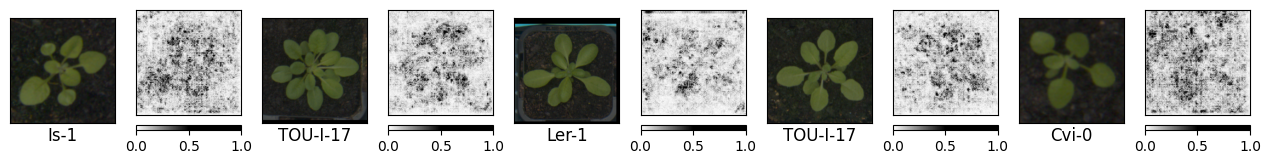

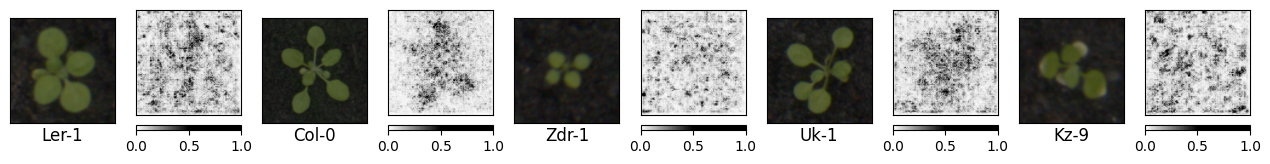

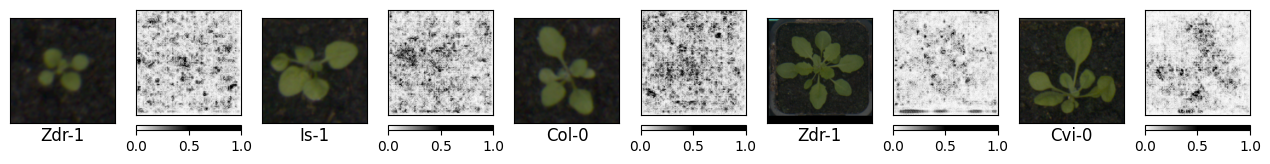

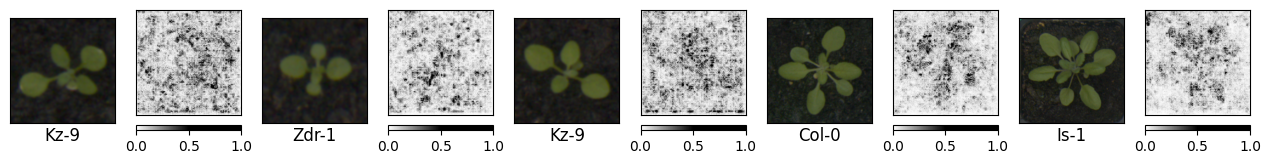

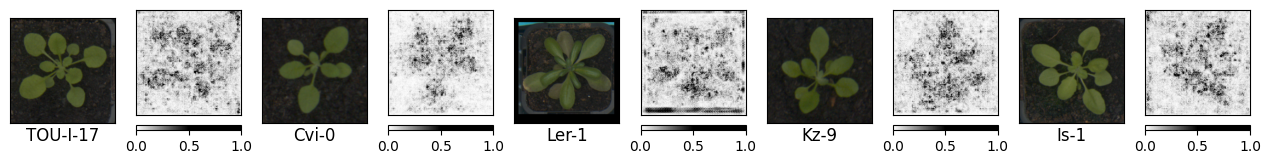

In [51]:
matplotlib.use('module://matplotlib_inline.backend_inline')

print("Current backend:", matplotlib.get_backend())
from matplotlib import pyplot as plt
import math

from captum.attr import Saliency
from captum.attr import visualization as viz
from matplotlib.colors import LinearSegmentedColormap

# Example
sample_size = 25 # please set to integral multiple of 5
cols = 10
row_entry = 0
loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=1, shuffle=True, drop_last=True)

# Create IntegratedGradients object and get attributes
saliency = Saliency(best_model)

for i, (images, labels) in enumerate(loader):
    if i == sample_size:
        break
    if row_entry % 5 == 0:
        fig, axes = plt.subplots(1, 10, figsize=(16,16))
        row_entry = 1
    else:
        row_entry += 1


    attributions_saliency = saliency.attribute(images.cuda().requires_grad_(), target=labels.type(torch.int64).cuda())

    # create custom colormap for visualizing the result
    default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                    [(0, '#ffffff'),
                                                    (0.5, '#000000'),
                                                    (1, '#000000')], N=256)

    # Get the class name for the label
    class_name = class_list[labels.item()]

    _ = viz.visualize_image_attr(np.transpose(attributions_saliency.squeeze().cpu().detach().numpy(), (1,2,0)),
                                np.transpose(images.squeeze().cpu().detach().numpy(), (1,2,0)),
                                method="original_image",
                                sign='positive',
                                fig_size=(4,3),
                                plt_fig_axis=(fig, axes[(i*2) % 10]),
                                use_pyplot=False
                                )

    # Set the title for the original image below the image
    axes[(i*2) % 10].set_title(class_name, y=-0.25)


    _ = viz.visualize_image_attr(np.transpose(attributions_saliency.squeeze().cpu().detach().numpy(), (1,2,0)),
                                np.transpose(images.squeeze().cpu().detach().numpy(), (1,2,0)),
                                method="heat_map",
                                sign='positive',
                                cmap=default_cmap,
                                fig_size=(4,3),
                                show_colorbar=True,
                                plt_fig_axis=(fig, axes[(i*2+1) % 10]),
                                use_pyplot=False
                                )

plt.show()